In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

d1 = pd.read_excel('PGCB_date_power_demand.xlsx')
raw_weather = pd.read_excel('weather_data.xlsx')
raw_econ   = pd.read_csv('economic_full_1.csv')

print("Demand", len(d1), ",Weather", len(raw_weather),",Economic", len(raw_econ))

Demand 92650 ,Weather 107307 ,Economic 1516


In [59]:
print(d1.head(3))
print(raw_weather.head(5))
print(raw_econ.head(3))

             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   

   india_adani  nepal remarks  
0          NaN    NaN     NaN  
1          NaN    NaN     NaN  
2          NaN    NaN     NaN  
              latitude            longitude                 elevation  \
0              23.7961              90.3805                         9   
1                  NaN                  NaN                       NaN   
2                 time  temperature_2m 

filling missing hours 89101
blank values 1055


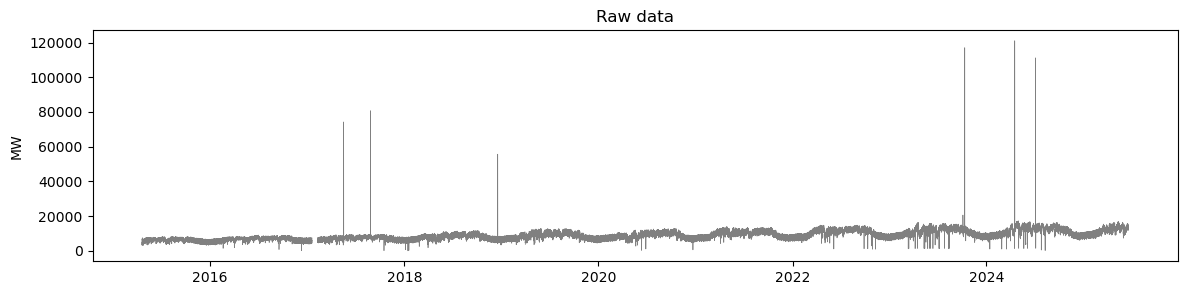

In [60]:
d = d1.sort_values('datetime')
d = d.drop_duplicates(subset='datetime', keep='first')

d = d.set_index('datetime')
d = d.resample('h').asfreq()

print("filling missing hours", len(d))
print("blank values", d['demand_mw'].isna().sum())

plt.figure(figsize=(14,3))
plt.plot(d.index, d['demand_mw'], linewidth=0.5, color='gray')
plt.title('Raw data')
plt.ylabel('MW')
plt.show()

In [61]:
def rolling_iqr_clean(series, window=24, k=1.5):
    q1 = series.rolling(window, center=True, min_periods=1).quantile(0.25)
    q3 = series.rolling(window, center=True, min_periods=1).quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

outliers = rolling_iqr_clean(d['demand_mw'], window=24, k=2.0)
print("Extreme values found:", outliers.sum())

Extreme values found: 481


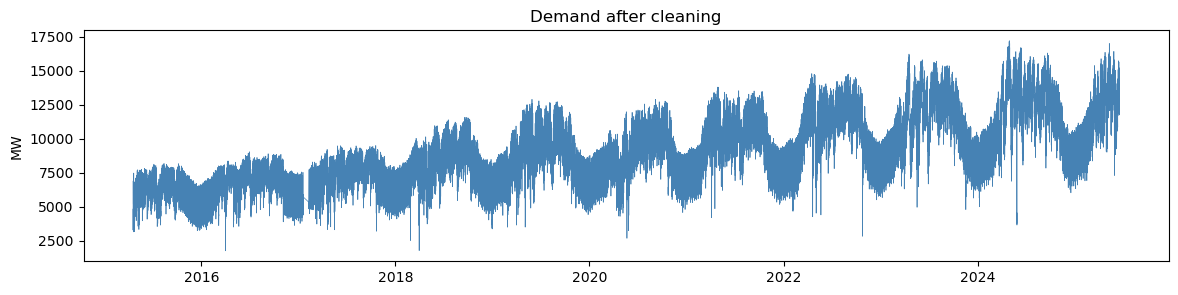

In [62]:
d['demand_mw'] = d['demand_mw'].mask(outliers)

d['demand_mw'] = d['demand_mw'].interpolate(method='time', limit_direction='forward')

d['demand_mw'] = d['demand_mw'].bfill()

plt.figure(figsize=(14,3))
plt.plot(d.index, d['demand_mw'], linewidth=0.5, color='steelblue')
plt.title('Demand after cleaning')
plt.ylabel('MW')
plt.show()

In [63]:
weather_raw = pd.read_excel('weather_data.xlsx', header=None)

time_row = None

for i in range(len(weather_raw)):
    
    if weather_raw.iloc[i, 0] == 'time':
        time_row = i
        break

col_names = weather_raw.iloc[time_row].tolist()

weather_clean = weather_raw.iloc[time_row + 1:].copy()

weather_clean.columns = col_names

weather_clean['time'] = pd.to_datetime(weather_clean['time'])

weather_clean = weather_clean.set_index('time').sort_index()

weather_clean = weather_clean.resample('h').ffill()

print(weather_clean.shape)
print(weather_clean.head(2))

(107304, 9)
                    temperature_2m (°C) relative_humidity_2m (%)  \
time                                                               
2014-01-01 00:00:00                13.9                       89   
2014-01-01 01:00:00                13.6                       91   

                    apparent_temperature (°C) precipitation (mm)  \
time                                                               
2014-01-01 00:00:00                      13.3                  0   
2014-01-01 01:00:00                      13.2                  0   

                    dew_point_2m (°C) soil_temperature_0_to_7cm (°C)  \
time                                                                   
2014-01-01 00:00:00              12.1                           16.4   
2014-01-01 01:00:00              12.1                             16   

                    wind_direction_10m (°) cloud_cover (%)  \
time                                                         
2014-01-01 00:00:00          

In [64]:
df = d[['demand_mw']].join(weather_clean, how='inner')

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

print(df.shape)

print(df.index.min().date(), df.index.max().date())

print(df.head(2))

(89101, 14)
2015-04-19 2025-06-17
                     demand_mw temperature_2m (°C) relative_humidity_2m (%)  \
2015-04-19 00:00:00     4821.0                25.7                       87   
2015-04-19 01:00:00     3612.0                25.3                       88   

                    apparent_temperature (°C) precipitation (mm)  \
2015-04-19 00:00:00                      29.6                  0   
2015-04-19 01:00:00                        30                  0   

                    dew_point_2m (°C) soil_temperature_0_to_7cm (°C)  \
2015-04-19 00:00:00              23.5                           26.7   
2015-04-19 01:00:00              23.2                           26.4   

                    wind_direction_10m (°) cloud_cover (%)  \
2015-04-19 00:00:00                    188               9   
2015-04-19 01:00:00                    151              26   

                    sunshine_duration (s)  hour  day_of_week  month  \
2015-04-19 00:00:00                     0     0 

In [65]:
useful = [
    "Population, total",
    "GDP growth (annual %)",
    "GDP per capita (constant 2015 US$)",
    "Access to electricity (% of population)",
    "Urban population (% of total population)",
]

econ_sel = raw_econ[raw_econ['Indicator Name'].isin(useful)].copy()

econ_sel = econ_sel.drop(columns=['Country Name', 'Indicator Code'])

econ_sel = econ_sel.set_index('Indicator Name').T
econ_sel.index = econ_sel.index.astype(int)
econ_sel.index.name = 'Year'
econ_sel = econ_sel.reset_index()

econ_sel = econ_sel.set_index('Year').ffill().reset_index()

econ_sel['match_year'] = econ_sel['Year'] + 1

print(econ_sel['match_year'].min(), econ_sel['match_year'].max())

1961 2026


In [71]:
df = df.copy()

df = df.reset_index()

df.rename(columns={'index': 'datetime'}, inplace=True)

df['datetime'] = pd.to_datetime(df['datetime'])

df = df.set_index('datetime')

df = df.drop(columns=['level_0'], errors='ignore')

In [53]:
print(econ_sel.columns.tolist())

['Year', 'GDP per capita (constant 2015 US$)', 'Access to electricity (% of population)', 'Urban population (% of total population)', 'Population, total', 'GDP growth (annual %)', 'match_year']


In [52]:
print(econ_sel.columns.tolist())
print(econ_sel.head(3))

['Year', 'GDP per capita (constant 2015 US$)', 'Access to electricity (% of population)', 'Urban population (% of total population)', 'Population, total', 'GDP growth (annual %)', 'match_year']
Indicator Name  Year  GDP per capita (constant 2015 US$)  \
0               1960                          429.398701   
1               1961                          442.754803   
2               1962                          453.534881   

Indicator Name  Access to electricity (% of population)  \
0                                                   NaN   
1                                                   NaN   
2                                                   NaN   

Indicator Name  Urban population (% of total population)  Population, total  \
0                                               5.112178         51828660.0   
1                                               5.277111         53310348.0   
2                                               5.465581         54881146.0   

Indicator N

In [50]:
df['year'] = df.index.year

df = df.reset_index().merge(
    econ_sel,
    left_on='year',
    right_on='match_year', 
    how='left'
).set_index('index')

df = df.drop(columns=['year', 'Year', 'match_year'], errors='ignore')

print(df.shape)

print("Economic columns added:", [c for c in df.columns if c in [
    "Population, total", "GDP growth (annual %)",
    "GDP per capita (constant 2015 US$)",
    "Access to electricity (% of population)",
    "Urban population (% of total population)"
]])

(88932, 31)
Economic columns added: []


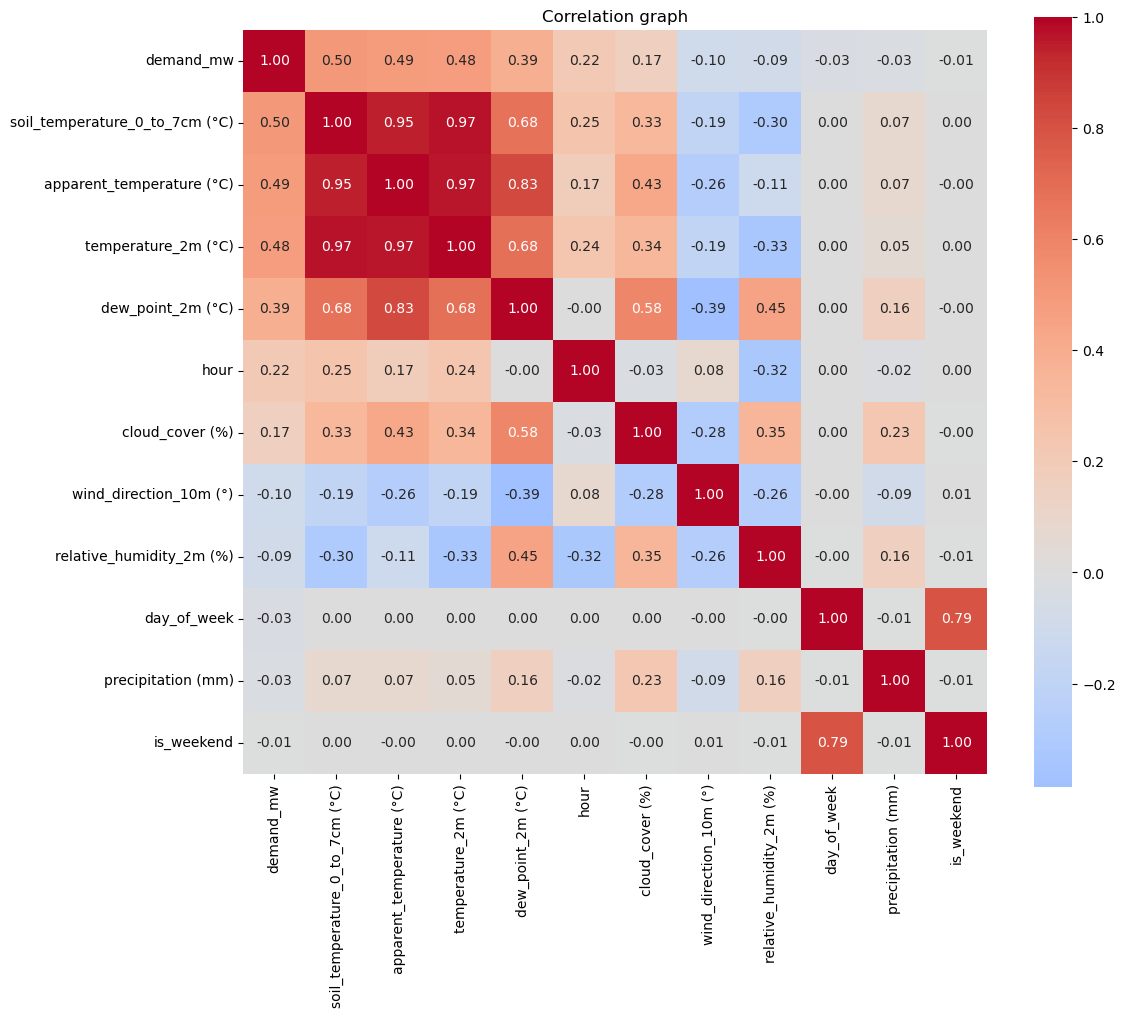

In [67]:
for col in df.columns:
    if col.endswith('_x') or col.endswith('_y'):
        df.drop(columns=col, inplace=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

import seaborn as sns
top_cols = df.corr()['demand_mw'].abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(12,10))
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation graph')
plt.show()

In [68]:
df['d_1h_ago']   = df['demand_mw'].shift(1)
df['d_2h_ago']   = df['demand_mw'].shift(2)
df['d_24h_ago']  = df['demand_mw'].shift(24)
df['d_168h_ago'] = df['demand_mw'].shift(168)

df['target'] = df['demand_mw'].shift(-1)

print(df.shape)

(89101, 19)


In [34]:
df['avg_d_3h']  = df['demand_mw'].shift(1).rolling(3).mean()
df['avg_d_24h'] = df['demand_mw'].shift(1).rolling(24).mean()

print(df.shape)

(89101, 21)


In [35]:
df = df.dropna()
print("Rows after removing blanks:", len(df))
print("Date range:", df.index.min().date(), "→", df.index.max().date())

Rows after removing blanks: 88932
Date range: 2015-04-26 → 2025-06-17


In [38]:
train = df[df.index.year < 2023].copy()
test  = df[df.index.year >= 2023].copy()
print("hours of training", len(train), ",hours of testing", len(test))

hours of training 67368 ,hours of testing 21564


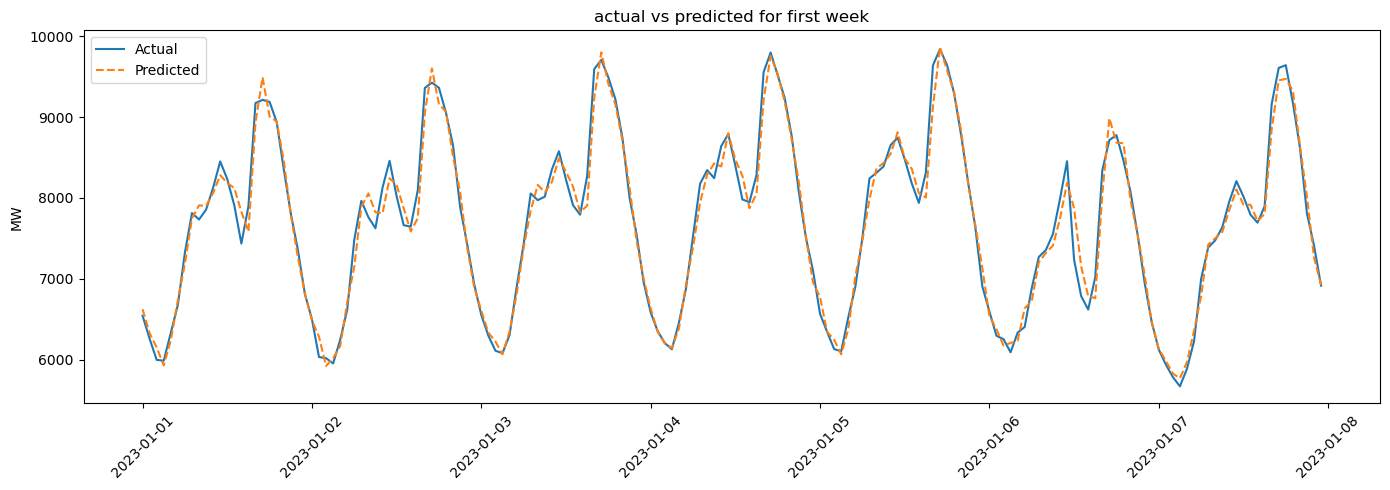

In [48]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:168], y_test.values[:168], label='Actual', linewidth=1.5)
plt.plot(y_test.index[:168], predictions[:168], label='Predicted', linestyle='--', linewidth=1.5)
plt.legend()
plt.title('actual vs predicted for first week')
plt.ylabel('MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

features = [c for c in df.columns if c != 'target']

for c in features:
    train[c] = pd.to_numeric(train[c], errors='coerce')
    test[c]  = pd.to_numeric(test[c], errors='coerce')

X_train, y_train = train[features], train['target']
X_test,  y_test  = test[features],  test['target']

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, predictions) * 100
print(f"mape= {mape:.2f}%")

mape= 2.48%


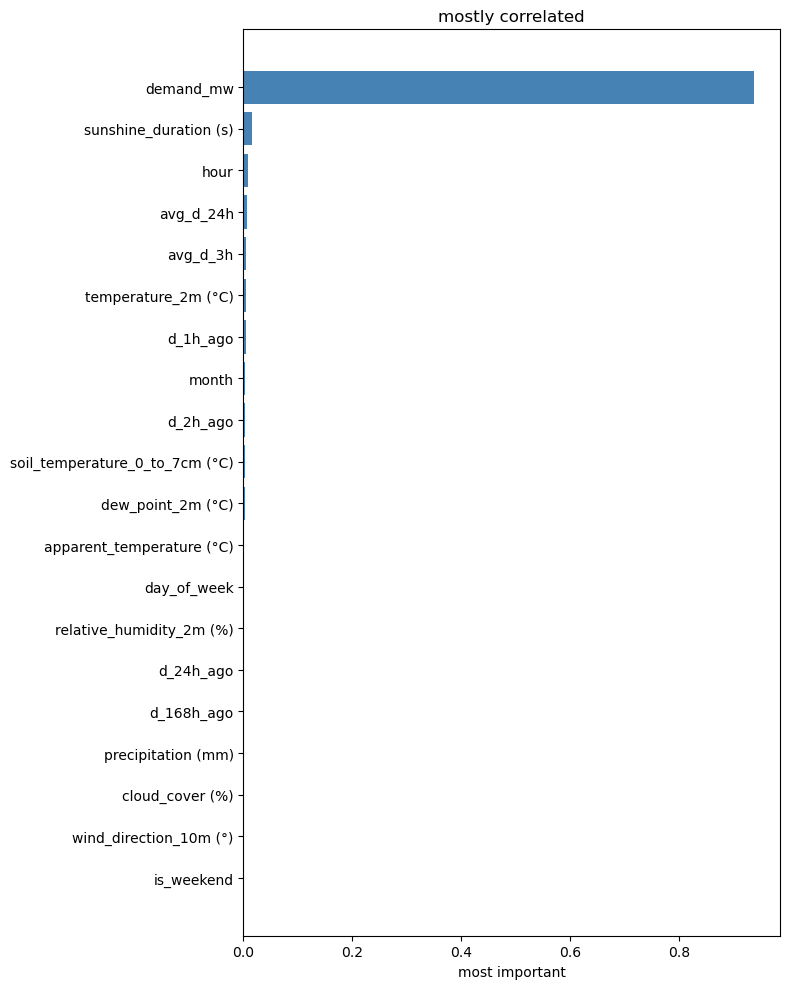

In [47]:
imp = pd.Series(model.feature_importances_, index=X_train.columns)
imp = imp.sort_values(ascending=True)

plt.figure(figsize=(8, 10))
plt.barh(imp.index, imp.values, color='steelblue')
plt.xlabel('most important')
plt.title('mostly correlated')
plt.tight_layout()
plt.show()